# Alpha geodesics on the space of Univariate Normal Distributions

> Objective: visualise the geodesics induced by the alpha connections on the space of univariate normal distributions, and compare with the Fisher geodesic. 

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

import geomstats.backend as gs
import geomstats.visualization as visualization
from geomstats.information_geometry.normal import (
    UnivariateNormalAlpha,
    UnivariateNormalDistributions,
)

## Data

In [29]:
riemannian_manifold = UnivariateNormalDistributions()
alphas = np.linspace(-1.0, 1.0, 21)
alphas_reduced = [-1.0, -0.5, 0.0, 0.5, 1.0]
space = UnivariateNormalDistributions(equip=False)
start_point = gs.array([0.0, 1.0])
end_point = gs.array([5, 1.0])
initial_tangent_vec = gs.array([0.5, 0.4])
end_time = 1.0

## Geodesic Point Generation

In [15]:
def truncate_at_singularity(points, sigma_min=1e-6, sigma_max=1e6):
    """Keep only the connected portion from the start, before the first singularity."""
    valid = (
        np.isfinite(points).all(axis=1)
        & (points[:, 1] > sigma_min)
        & (points[:, 1] < sigma_max)
    )
    if valid.all():
        return points
    first_invalid = np.argmax(~valid)
    return points[:first_invalid]


def alpha_geodesic_ivp(alpha, riemannian_manifold, space, start_point, initial_tangent_vec, end_time=1.0, nb_points=50):
    """Compute the geodesic with respect to the alpha-connection."""
    space.equip_with_connection(
        UnivariateNormalAlpha, 
        riemannian_manifold=riemannian_manifold, 
        alpha=alpha,
    )
    points = space.connection.geodesic(
    initial_point=start_point,
    initial_tangent_vec=initial_tangent_vec)(gs.linspace(0.0, end_time, nb_points))
    return truncate_at_singularity(points)

def fisher_rao_geodesic_ivp(riemannian_manifold, start_point, initial_tangent_vec, end_time=1.0, nb_points=30):
    """Compute the geodesic with respect to the Fisher-Rao metric."""
    points = riemannian_manifold.metric.geodesic(
        initial_point=start_point,
        initial_tangent_vec=initial_tangent_vec
    )(gs.linspace(0.0, end_time, nb_points))
    return truncate_at_singularity(points)


def dict_alpha_geodesic_ivp(alphas, riemannian_manifold, space, start_point, initial_tangent_vec, end_time=1.0, nb_points=30):
    """Compute and store geodesics with respect to the alpha-connection for each alpha value."""
    geodesics = {}
    for alpha in alphas:
        geodesics[alpha] = alpha_geodesic_ivp(
            alpha, 
            riemannian_manifold, 
            space, 
            start_point, 
            initial_tangent_vec, 
            end_time, 
            nb_points)
    return geodesics


In [16]:
def alpha_geodesic_bvp(alpha, riemannian_manifold, space, start_point, end_point, end_time=1.0, nb_points=50):
    """Compute the geodesic with respect to the alpha-connection."""
    space.equip_with_connection(
        UnivariateNormalAlpha, 
        riemannian_manifold=riemannian_manifold, 
        alpha=alpha,
    )
    points = space.connection.geodesic(
        initial_point=start_point,
        end_point=end_point
        )(gs.linspace(0.0, end_time, nb_points))
    return truncate_at_singularity(points)

def fisher_rao_geodesic_bvp(riemannian_manifold, start_point, end_point, end_time=1.0, nb_points=30):
    """Compute the geodesic with respect to the Fisher-Rao metric."""
    points = riemannian_manifold.metric.geodesic(
        initial_point=start_point,
        end_point=end_point
        )(gs.linspace(0.0, end_time, nb_points))
    return truncate_at_singularity(points)

def dict_alpha_geodesic_bvp(alphas, riemannian_manifold, space, start_point, end_point, end_time=1.0, nb_points=30):
    """Compute and store geodesics with respect to the alpha-connection for each alpha value."""
    geodesics = {}
    for alpha in alphas:
        geodesics[alpha] = alpha_geodesic_bvp(
            alpha, 
            riemannian_manifold, 
            space, 
            start_point, 
            end_point, 
            end_time, 
            nb_points)
    return geodesics

## Geodesics in the Density Space

### Plot Algorithms

In [17]:
def plot_geodesics_ivp(dict_points, fisher_rao_geodesic, point_init, x_min=-1, x_max=5):

    _ , ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(point_init[0], 
            point_init[1], 
            marker="x", 
            markersize=10, 
            color="red", 
            label="Initial point")

    colors = plt.cm.viridis(np.linspace(0, 1, len(dict_points.keys())))
    for i, alpha in enumerate(dict_points.keys()):
        points = dict_points[alpha]
        ax.plot(points[:, 0], 
                points[:, 1], 
                linestyle="--",
                marker="None",
                color=colors[i],
                label=r"$\alpha$= " + f"{alpha:.4f}")

    ax.plot(fisher_rao_geodesic[:, 0], 
            fisher_rao_geodesic[:, 1], 
            linestyle="None",
            marker="o",
            markersize=2,
            alpha=0.5,
            color="black", 
            label="Fisher-Rao geodesic")


    

    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    ax.set_title("$\\alpha$-geodesics (IVP problem) of the Univariate Normal Distribution space", fontsize=16)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_geodesics_bvp(dict_points, fisher_rao_geodesic, point_init, point_end, x_min=-1, x_max=5):

    _ , ax = plt.subplots(figsize=(10, 5))

    ax.plot(point_init[0], 
            point_init[1], 
            marker="x", 
            markersize=10, 
            color="red", 
            label="Initial point")

    ax.plot(point_end[0], 
            point_end[1], 
            marker="x", 
            markersize=10, 
            color="blue", 
            label="End point")

    colors = plt.cm.viridis(np.linspace(0, 1, len(dict_points.keys())))
    for i, alpha in enumerate(dict_points.keys()):
        points = dict_points[alpha]
        ax.plot(points[:, 0], 
                points[:, 1], 
                linestyle="--",
                marker="None",
                color=colors[i],
                label=r"$\alpha$= " + f"{alpha:.4f}")


    ax.plot(fisher_rao_geodesic[:, 0],
            fisher_rao_geodesic[:, 1],
            linestyle="None",
            marker="o",
            markersize=2,
            alpha=0.5,
            color = "black",
            label="Fisher-Rao geodesic")
    

    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    ax.set_title("$\\alpha$-geodesics of the Univariate Normal Distribution space", fontsize=16)
    plt.tight_layout()
    plt.show()

### Results (BVP)

In [19]:
fish_rao_geodesic_bvp = fisher_rao_geodesic_bvp(riemannian_manifold, start_point, end_point)
dict_points_bvp = dict_alpha_geodesic_bvp(alphas, riemannian_manifold, space, start_point, end_point)

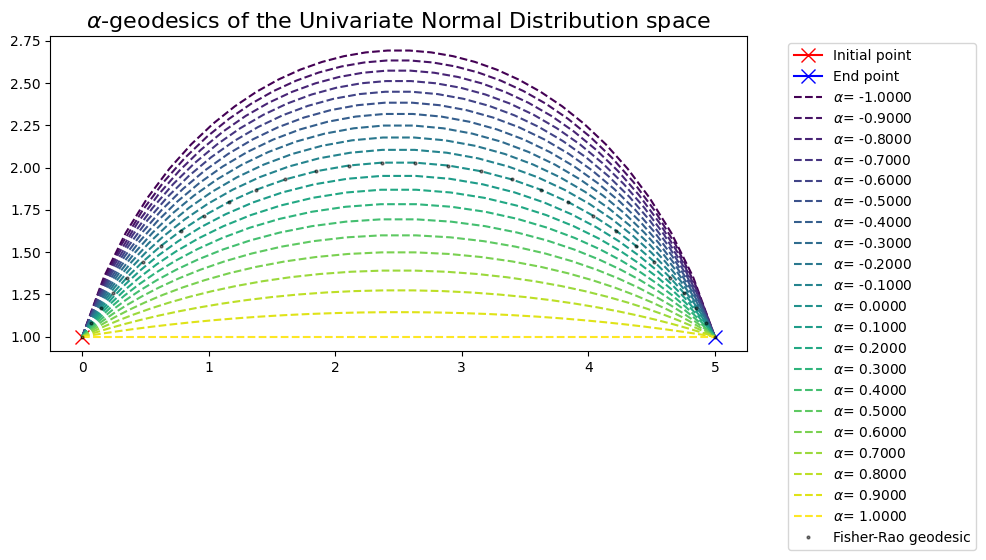

In [20]:
plot_geodesics_bvp(dict_points_bvp, fish_rao_geodesic_bvp, start_point, end_point)

We have, for $\alpha =1$, 

$$\sigma(t)  =  \sqrt{\frac{1}{(1-t)\sigma_0 ^{-2} + t \sigma_1 ^{-2}}}$$
    
$$\mu(t) = \sigma(t)^2 \cdot [(1-t) \frac{\mu_0}{\sigma_0^2} + t \frac{\mu_1}{\sigma_1 ^2}] \\$$
so that when $\sigma_0 = \sigma_1$, the geodesic is a straight line ($\sigma(t)$ is constant) for this choice of parametrization. This is due to the fact that Gaussian distributions form an exponential family. In natural coordinates $(\Lambda(t),\eta(t))= (-\frac{1}{2\sigma ^2}(t),\frac{\mu}{\sigma^2}(t))$, the geodesics are straight lines. 

### Results (IVP)

In [30]:
fish_rao_geodesic_ivp = fisher_rao_geodesic_ivp(riemannian_manifold, start_point, initial_tangent_vec)
dict_points_ivp = dict_alpha_geodesic_ivp(alphas_reduced, riemannian_manifold, space, start_point, initial_tangent_vec)

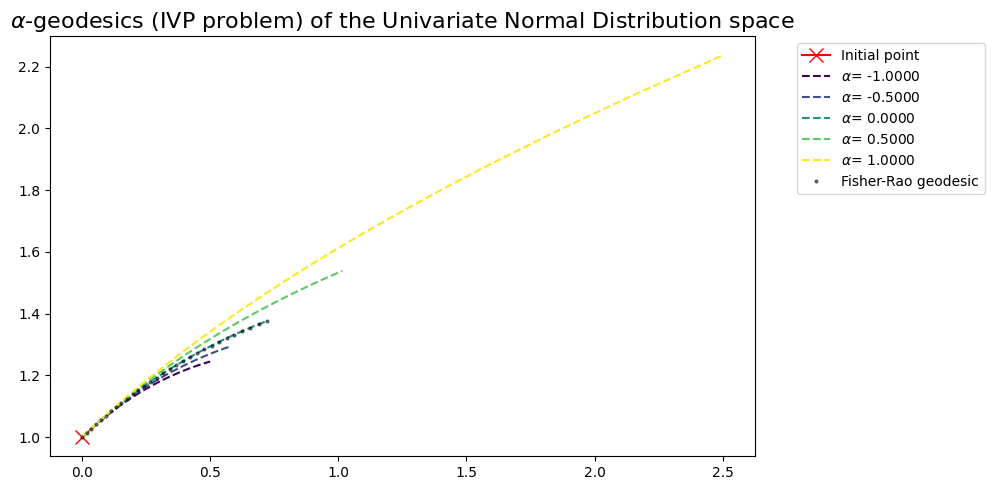

In [31]:
plot_geodesics_ivp(dict_points_ivp, fish_rao_geodesic_ivp, start_point)

the $\alpha=1$-geodesic seams to be a straight line, but it is not. The coordinates we introduced earlier apply here, and it is only in the parametrization with natural coordinates that we can actually observe straight lines for $1$-geodesics. 

## Density Visualization

### Plot Algorithm

In [23]:
def plot_densities(points_dict,fisher_rao_geodesic, x_min, x_max):
    x = np.linspace(x_min, x_max, 200)

    chosen_alphas = list(points_dict.keys())
    chosen_alphas = [chosen_alphas[0], chosen_alphas[len(chosen_alphas) // 2], chosen_alphas[-1]]
    colors = plt.cm.viridis(np.linspace(0, 1, len(chosen_alphas)))
    _, ax = plt.subplots(figsize=(10, 5))
    for i, alpha in enumerate(chosen_alphas):
         points = points_dict[alpha]
         for j,(mu, sigma) in enumerate(points):  
            ax.plot(x, 
                    norm.pdf(x, mu, sigma),
                    linestyle="--",
                    linewidth=1,
                    color = colors[i],
                    label=r"$\alpha$= " + f"{alpha:.4f}" if j == 0 else "")
    ax.set_title("Comparison of densities along the $\\alpha$-geodesics", fontsize=16)
    plt.legend()
    plt.tight_layout()
    plt.show()

    for alpha, points in points_dict.items():
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.set_title(r"$\alpha$= " + f"{alpha:.4f}", fontsize=14)
        for (mu, sigma) in points:  
            ax.plot(x, 
                    norm.pdf(x, mu, sigma),
                    linestyle="--",
                    linewidth=1,
                    color = "black")
        plt.tight_layout()
        plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title("Fisher-Rao geodesic", fontsize=14)    
    for (mu, sigma) in fisher_rao_geodesic:
        ax.plot(x, 
                norm.pdf(x, mu, sigma),
                linestyle="-",
                linewidth=1,
                color = "red")
    
    plt.tight_layout()
    plt.show()


### Results

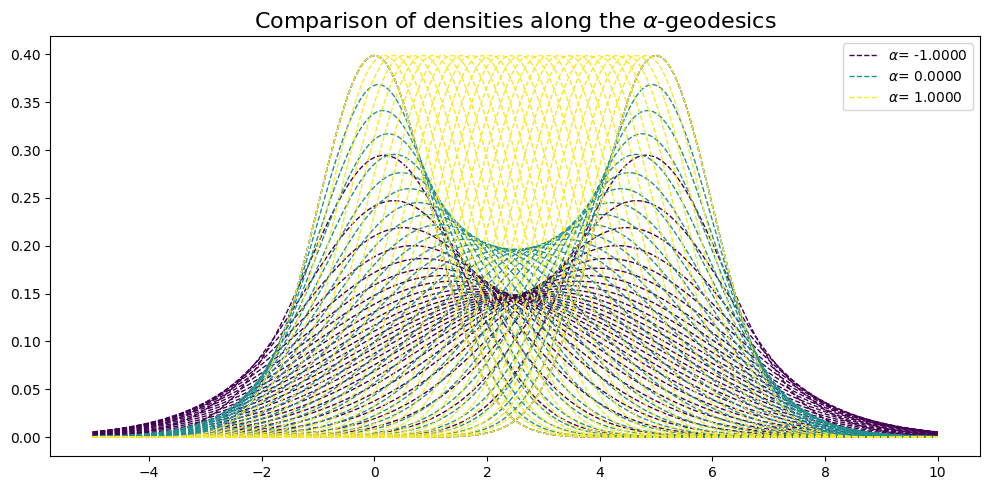

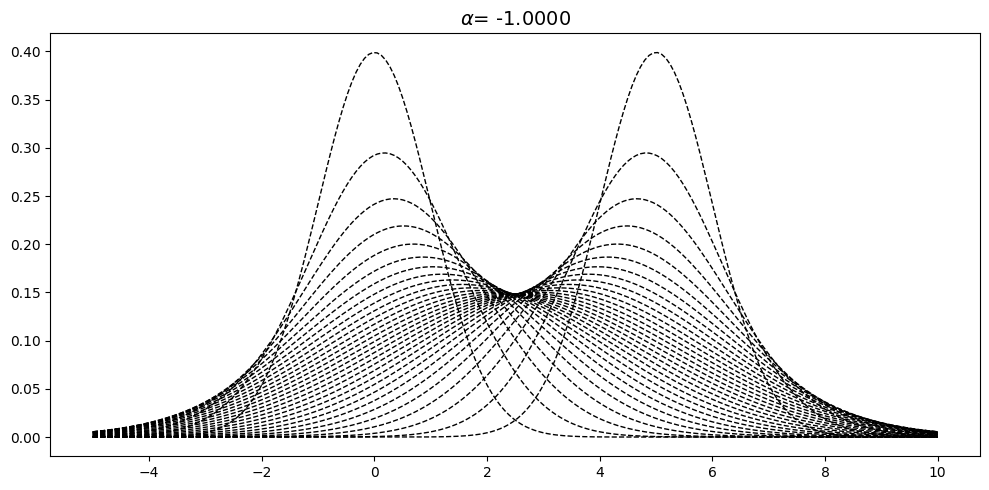

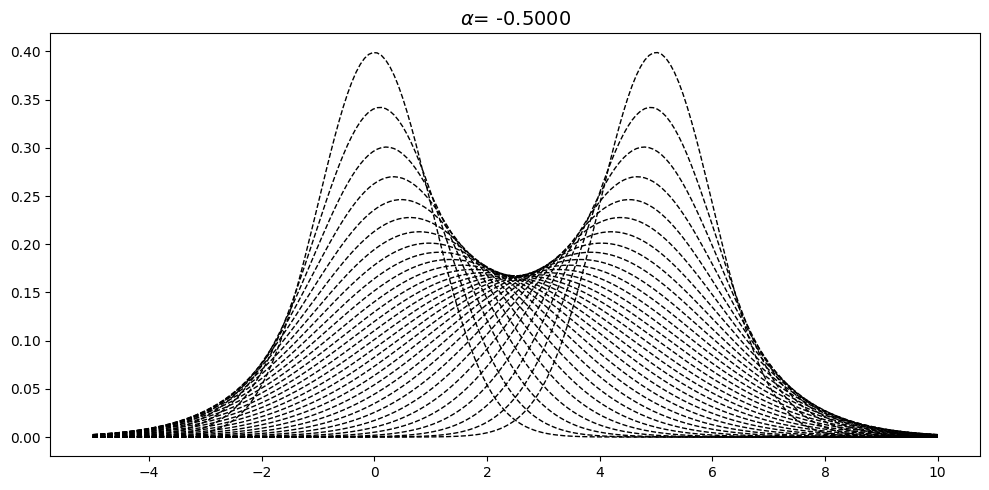

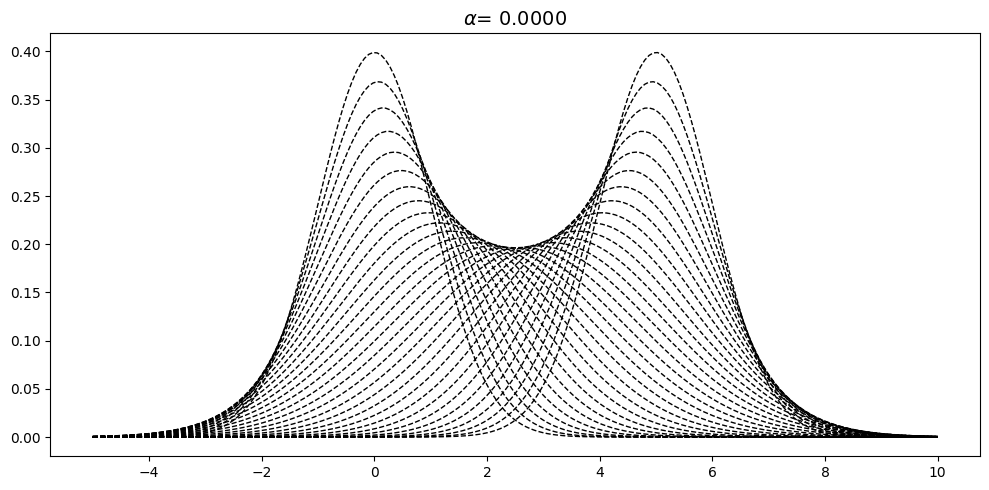

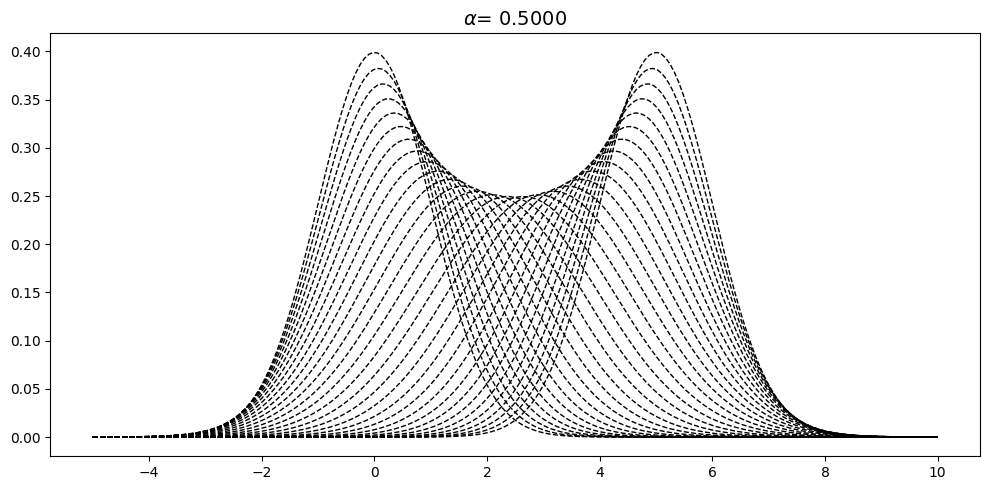

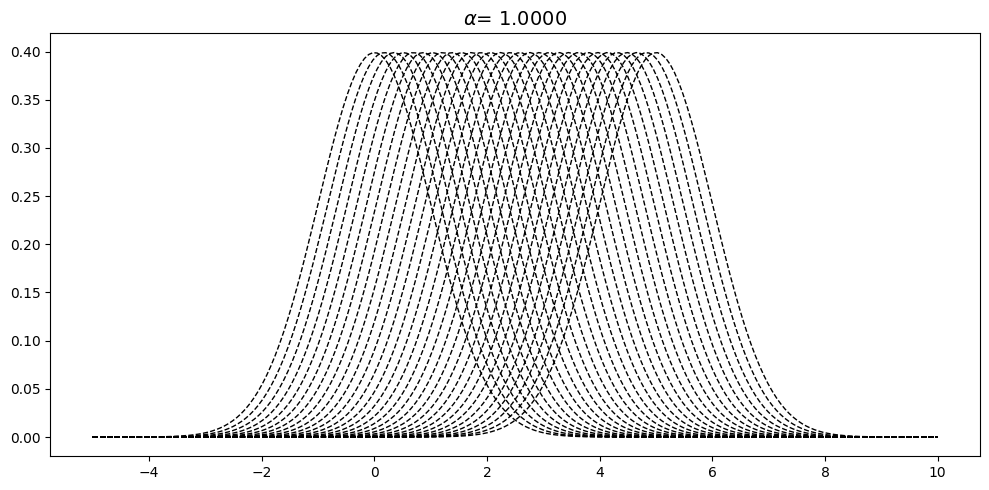

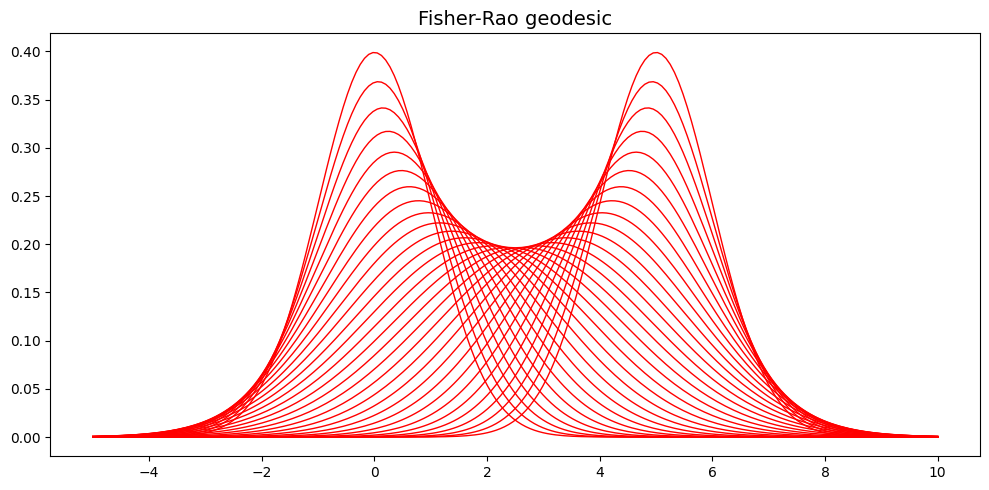

In [24]:
fish_rao_geodesic = fisher_rao_geodesic_bvp(riemannian_manifold, start_point, end_point)
dict_points = dict_alpha_geodesic_bvp(alphas_reduced, riemannian_manifold, space, start_point, end_point)
plot_densities(points_dict= dict_points,fisher_rao_geodesic= fish_rao_geodesic, x_min=-5.0, x_max=10.0)